<a href="https://colab.research.google.com/github/basha1818/Animal-Protection-Awareness-System/blob/main/walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load Dataset
data=pd.read_csv("/content/Walmart.csv")

In [5]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
# Check for missing values
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [10]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [11]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week.astype(int)

In [12]:
# Drop target + unnecessary columns
X = data.drop(['Weekly_Sales', 'Date'], axis=1)

# Target variable
y = data['Weekly_Sales']

In [13]:
print(X.head())
print(y.head())

   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0      1             0        42.31       2.572  211.096358         8.106   
1      1             1        38.51       2.548  211.242170         8.106   
2      1             0        39.93       2.514  211.289143         8.106   
3      1             0        46.63       2.561  211.319643         8.106   
4      1             0        46.50       2.625  211.350143         8.106   

   Year  Month  Week  
0  2010      2     5  
1  2010      2     6  
2  2010      2     7  
3  2010      2     8  
4  2010      3     9  
0    1643690.90
1    1641957.44
2    1611968.17
3    1409727.59
4    1554806.68
Name: Weekly_Sales, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 432594.97688780207


In [19]:
from sklearn.ensemble import RandomForestRegressor

In [20]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [21]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
y_pred_rf = rf.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest MSE:", mse_rf)

Random Forest MAE: 63197.56307614608
Random Forest MSE: 13365855228.832611


In [24]:
print("Linear Regression MAE:", mae_lr)
print("Random Forest MAE:", mae_rf)

NameError: name 'mae_lr' is not defined

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)

print("Linear Regression MAE:", mae_lr)

Linear Regression MAE: 432594.97688780207


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)

Random Forest MAE: 63197.56307614608


In [27]:
print("Linear Regression MAE:", mae_lr)
print("Random Forest MAE:", mae_rf)

Linear Regression MAE: 432594.97688780207
Random Forest MAE: 63197.56307614608


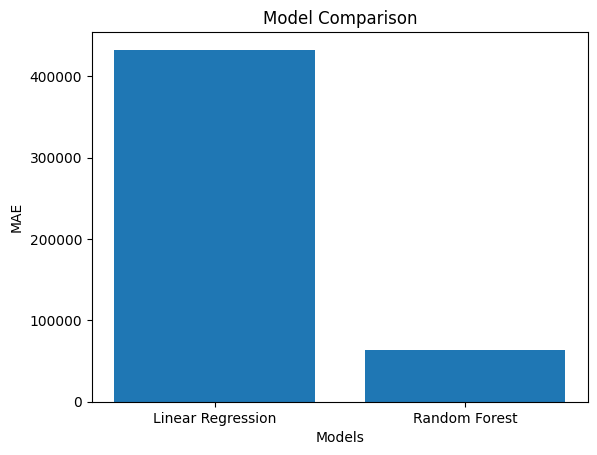

In [28]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
mae_values = [mae_lr, mae_rf]

plt.bar(models, mae_values)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.show()

In [29]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, y_pred)
print("Linear Regression R2:", r2_lr)

Linear Regression R2: 0.1555316049960288


In [30]:
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R2:", r2_rf)

Random Forest R2: 0.9585110481236588


In [31]:
print("Linear Regression R2:", r2_lr)
print("Random Forest R2:", r2_rf)

Linear Regression R2: 0.1555316049960288
Random Forest R2: 0.9585110481236588
